In [3]:
# IMPORT LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1780722506.543355     405 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780722508.681425     405 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780722514.767499     405 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
# LOAD DATASET

In [8]:
df = pd.read_csv("TSLA.csv")

print(df.head())
print(df.shape)

         Date       Open   High        Low      Close  Adj Close    Volume
0  2010-06-29  19.000000  25.00  17.540001  23.889999  23.889999  18766300
1  2010-06-30  25.790001  30.42  23.299999  23.830000  23.830000  17187100
2  2010-07-01  25.000000  25.92  20.270000  21.959999  21.959999   8218800
3  2010-07-02  23.000000  23.10  18.709999  19.200001  19.200001   5139800
4  2010-07-06  20.000000  20.00  15.830000  16.110001  16.110001   6866900
(2416, 7)


In [9]:
# DATA CLEANING

In [10]:
print(df.isnull().sum())

df.dropna(inplace=True)

print("After cleaning:", df.shape)

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
After cleaning: (2416, 7)


In [11]:
# CONVERT DATA COLUMN

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

df.sort_values('Date', inplace=True)

df.set_index('Date', inplace=True)

In [13]:
# USE CLOSE PRICE

In [15]:
close_price = df[['Close']]

In [16]:
# VISUALIZATION

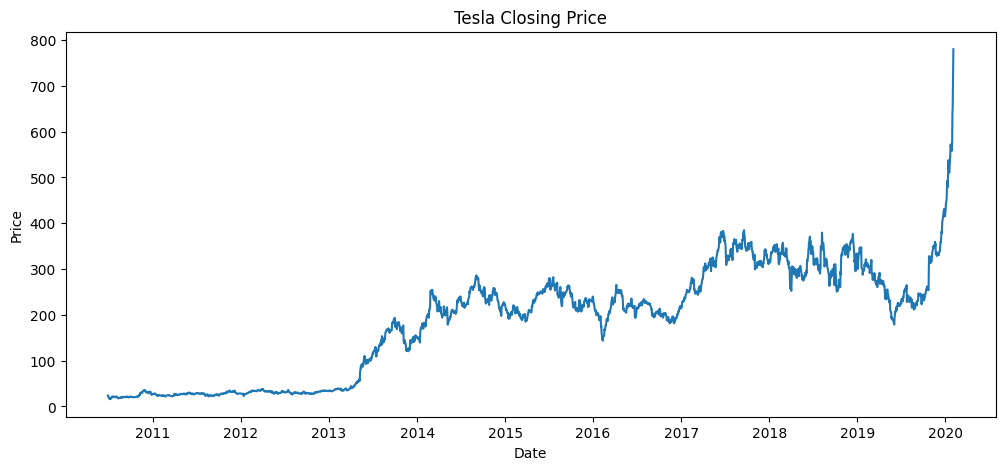

In [17]:
plt.figure(figsize=(12,5))
plt.plot(close_price)
plt.title("Tesla Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [18]:
# SCALING

In [19]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_price)

In [20]:
# CREATE SEQUENCES

In [21]:
def create_dataset(data, time_step=60):

    X = []
    y = []

    for i in range(len(data)-time_step):

        X.append(data[i:(i+time_step),0])

        y.append(data[i+time_step,0])

    return np.array(X), np.array(y)

In [22]:
# TRAIN TEST SPLIT

In [23]:
train_size = int(len(scaled_data)*0.8)

train_data = scaled_data[:train_size]

test_data = scaled_data[train_size:]

In [24]:
# PREPARE DATA

In [25]:
time_step = 60

X_train, y_train = create_dataset(train_data,time_step)

X_test, y_test = create_dataset(test_data,time_step)

X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],1)

X_test = X_test.reshape(X_test.shape[0],X_test.shape[1],1)

print(X_train.shape)
print(X_test.shape)

(1872, 60, 1)
(424, 60, 1)


In [26]:
# BUILD SIMPLERNN

In [27]:
rnn_model = Sequential()

rnn_model.add(SimpleRNN(64,
                        return_sequences=True,
                        input_shape=(60,1)))

rnn_model.add(Dropout(0.2))

rnn_model.add(SimpleRNN(32))

rnn_model.add(Dropout(0.2))

rnn_model.add(Dense(1))

rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

rnn_model.summary()

E0000 00:00:1780723060.939104     405 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,361 (28.75 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# TRAIN SIMPLERNN

In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "../models/best_rnn_model.keras",
    save_best_only=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop,checkpoint]
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0375 - val_loss: 0.0112
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0096 - val_loss: 0.0031
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0062 - val_loss: 9.1550e-04
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0043 - val_loss: 7.9039e-04
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0036 - val_loss: 0.0010
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0028 - val_loss: 6.7302e-04
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0024 - val_loss: 5.1339e-04
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0021 - val_loss: 0.0010
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0017 - val_loss: 4.3204e-04
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0017 - val_loss: 3.0134e-04
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0016 - val_loss: 4.1697e-04
Epoch 12/50
47/47 ━━━━━━━━━━━━━━━━━

In [30]:
# BUILD LSTM

In [31]:
lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(60,1)
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(32))

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# TRAIN LSTM

In [33]:
checkpoint2 = ModelCheckpoint(
    "../models/best_lstm_model.keras",
    save_best_only=True
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop,checkpoint2]
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0038 - val_loss: 5.8549e-04
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 6.4047e-04 - val_loss: 4.0000e-04
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 5.5675e-04 - val_loss: 3.7170e-04
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 5.6546e-04 - val_loss: 5.1866e-04
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 5.0932e-04 - val_loss: 5.7946e-04


In [34]:
# PREDICT

In [35]:
rnn_pred = rnn_model.predict(X_test)

lstm_pred = lstm_model.predict(X_test)

rnn_pred = scaler.inverse_transform(rnn_pred)

lstm_pred = scaler.inverse_transform(lstm_pred)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


In [36]:
# CALCULATE MSE

In [37]:
rnn_mse = mean_squared_error(
    y_test_actual,
    rnn_pred
)

lstm_mse = mean_squared_error(
    y_test_actual,
    lstm_pred
)

print("RNN MSE :", rnn_mse)

print("LSTM MSE :", lstm_mse)

RNN MSE : 505.62074210477306
LSTM MSE : 924.8525754494274


In [38]:
# PLOT RNN

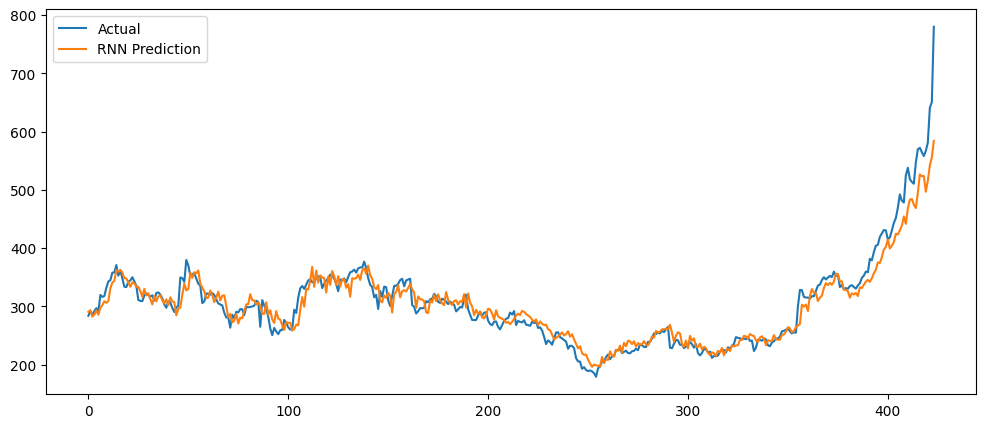

In [42]:
plt.figure(figsize=(12,5))

plt.plot(y_test_actual,label='Actual')

plt.plot(rnn_pred,label='RNN Prediction')

plt.legend()

plt.savefig(
    "outputs/actual_vs_predicted_rnn.png"
)

plt.show()

In [41]:
import os
print(os.getcwd())

/home/5fb4de6a-6f72-48ac-9bbb-ca216256be40/Tesla_Stock_Prediction


In [43]:
# COMPARE MODELS

In [45]:
comparison = pd.DataFrame({

    'Model':['SimpleRNN','LSTM'],

    'MSE':[rnn_mse,lstm_mse]

})

comparison.to_csv(
    "outputs/comparison_results.csv",
    index=False
)

comparison

,Model,MSE
0,SimpleRNN,505.620742
1,LSTM,924.852575


In [46]:
# FUTURE PREDICTION FUNCTION(1 DAY,5 DAYS, 10 DAYS)

In [52]:
def future_prediction(model, last_sequence, days):

    temp = list(last_sequence.flatten())

    predictions = []

    for i in range(days):

        x = np.array(temp[-60:])
        x = x.reshape(1, 60, 1)

        pred = model.predict(x, verbose=0)

        pred_value = pred[0][0]

        predictions.append(pred_value)

        temp.append(pred_value)

    predictions = np.array(predictions).reshape(-1, 1)

    return scaler.inverse_transform(predictions)

In [48]:
# PREDICT FUTURE

In [53]:
last_seq = scaled_data[-60:]

future_1 = future_prediction(
    lstm_model,
    last_seq,
    1
)

future_5 = future_prediction(
    lstm_model,
    last_seq,
    5
)

future_10 = future_prediction(
    lstm_model,
    last_seq,
    10
)

print("1 Day Prediction")
print(future_1)

print("5 Day Prediction")
print(future_5)

print("10 Day Prediction")
print(future_10)

1 Day Prediction
[[568.27637]]
5 Day Prediction
[[568.27637]
 [578.5316 ]
 [586.23303]
 [591.8954 ]
 [596.02576]]
10 Day Prediction
[[568.27637]
 [578.5316 ]
 [586.23303]
 [591.8954 ]
 [596.02576]
 [599.0324 ]
 [601.23267]
 [602.86566]
 [604.10706]
 [605.08246]]


In [6]:
import os

print(os.path.exists("best_rnn_model.h5"))
print(os.path.exists("best_lstm_model.h5"))

False
False


In [8]:
from tensorflow.keras.models import load_model

rnn_model = load_model("models/best_rnn_model.keras")
lstm_model = load_model("models/best_lstm_model.keras")

rnn_model.save("models/best_rnn_model.h5")
lstm_model.save("models/best_lstm_model.h5")

print("Saved successfully")

E0000 00:00:1780727179.092103    2023 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Saved successfully


In [9]:
import os

print(os.path.exists("models/best_rnn_model.h5"))
print(os.path.exists("models/best_lstm_model.h5"))

True
True


In [10]:
from tensorflow.keras.models import load_model

rnn_model = load_model("models/best_rnn_model.keras")
lstm_model = load_model("models/best_lstm_model.keras")

rnn_model.summary()
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,085 (86.27 KB)

 Trainable params: 7,361 (28.75 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,037 (343.90 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 58,692 (229.27 KB)